#**Lab 1: Data Preparation & Exploration**
Working with custom datasets is a fundamental skill for any deep learning practitioner. Instead of relying on pre-built datasets, you'll often need to prepare and load your own data. In this lab, we'll learn how to download, explore, and visualize image data for a food classification task.

**Project Overview: PyTorch Custom Datasets**

In this project series, we'll follow the standard PyTorch workflow to build an image classification model from scratch using custom data.

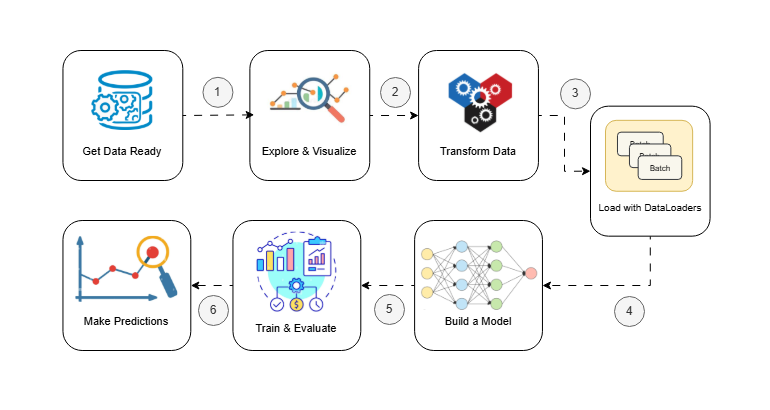

The workflow consists of 7 key steps:

1. Get Data Ready — Download and prepare custom image data
2. Explore & Visualize — Understand your data before modeling
3. Transform Data — Convert images to tensors with proper preprocessing
4. Load with DataLoaders — Create iterable batches for training
5. Build a Model — Create a CNN architecture (TinyVGG)
6. Train & Evaluate — Fit the model and measure performance
7. Make Predictions — Use the trained model on new images

**What is a Custom Dataset?**

A custom dataset is a collection of data relating to a specific problem you're working on. Unlike pre-built datasets (like MNIST or CIFAR-10), custom datasets are:

* Collected specifically for your use case
* May require special preprocessing
* Often stored in local directories or cloud storage
Examples of Custom Datasets:

* Food images - For a food classification app like Nutrify
* Text reviews - Customer reviews with ratings for sentiment classification
* Sound samples - Audio recordings with labels for sound classification
* Product data - Purchase history for recommendation systems
PyTorch includes functions to load various custom datasets in TorchVision, TorchText, TorchAudio and TorchRec domain libraries.

**Our Problem: Food Classification**

We're building a model to classify images of pizza, steak, and sushi.



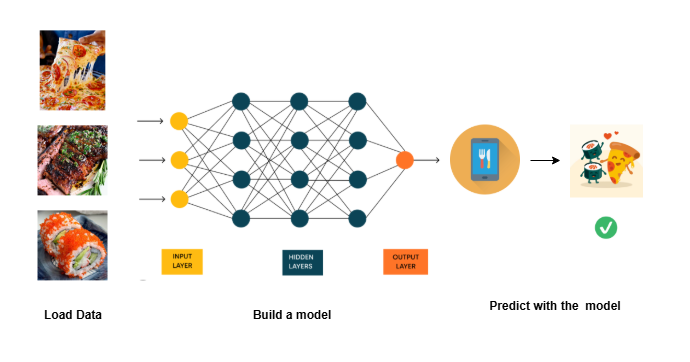

Given an image of food, our model should predict which class it belongs to:

* Class 0: Pizza
* Class 1: Steak
* Class 2: Sushi

**Goal of This Lab**

In this first lab, we focus on getting the data ready and understanding it through visualization.

What we'll learn:

1. How to download and extract image data programmatically
2. How to explore directory structure of image datasets
3. How to visualize images using PIL and matplotlib
4. The importance of data exploration before modeling

## Part 1: Understanding the Data Source

### The Food-101 Subset

Our data is a subset of the **Food-101 dataset**, which originally contains **101,000 images across 101 food categories**.

We are starting small with just **3 classes**:

1. **Pizza** — ~75 training images, ~25 test images  
2. **Steak** — ~75 training images, ~25 test images  
3. **Sushi** — ~75 training images, ~25 test images  

---


**Why Start Small?**

Machine learning is an iterative process. Starting with a small dataset allows us to:

* Quickly prototype and test our pipeline
* Identify issues early before scaling up
* Reduce computational costs during development
* Once our pipeline works, we can easily scale to larger datasets.

**Part 2: Data Directory Structure**

Standard Image Classification Format
PyTorch expects image data in a specific directory structure:

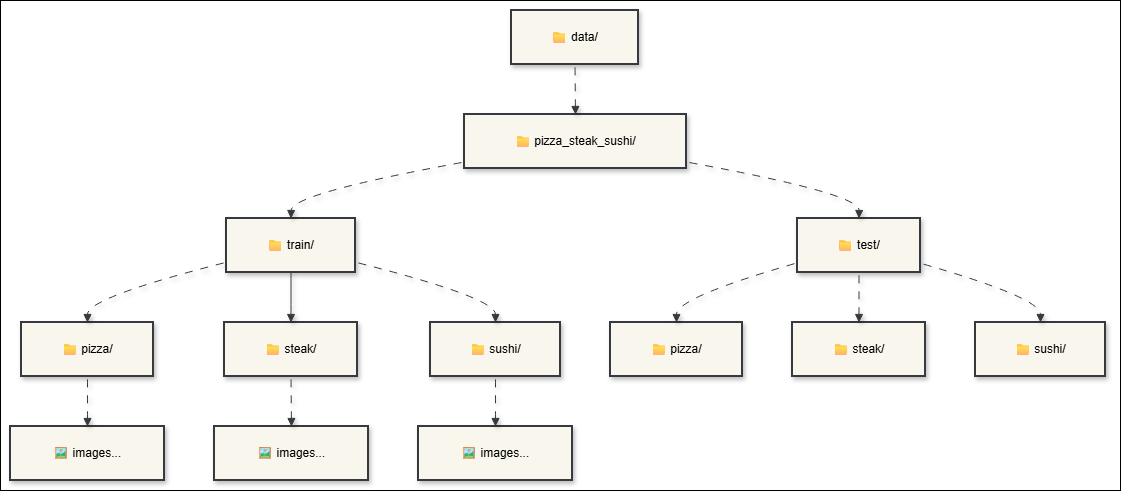

Each class has its own subdirectory, and the folder name becomes the class label. This is the ImageFolder format that PyTorch can automatically process.

**Part 3: Data Exploration**

Walking Through the Directory
Before building any model, we need to understand our data. The os.walk() function helps us explore the directory structure:

In [ ]:
import os

def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.')


This function tells us:

How many subdirectories exist at each level
How many images are in each folder
The overall structure of our dataset

চলো কোডটা লাইন ধরে সহজভাবে বুঝি 👇

```python
import os

def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.')
```

---

# 🔹 1️⃣ `import os`

👉 `os` হলো Python-এর built-in module
👉 এটা দিয়ে file system (folder, file, path) নিয়ে কাজ করা যায়

---

# 🔹 2️⃣ `def walk_through_dir(dir_path):`

এখানে আমরা একটি function বানাচ্ছি যার নাম `walk_through_dir`

`dir_path` = যে folder path তুমি inspect করতে চাও

উদাহরণ:

```python
walk_through_dir("data/")
```

---

# 🔹 3️⃣ `os.walk(dir_path)`

এটাই সবচেয়ে গুরুত্বপূর্ণ অংশ।

`os.walk()`:

* পুরো directory tree ঘুরে দেখে
* প্রতিটি folder এর জন্য ৩টা জিনিস দেয়:

| Variable    | Meaning                             |
| ----------- | ----------------------------------- |
| `dirpath`   | বর্তমান folder এর path              |
| `dirnames`  | ওই folder এর ভিতরের sub-folder list |
| `filenames` | ওই folder এর ভিতরের file list       |

---

# 🔹 4️⃣ `for dirpath, dirnames, filenames in os.walk(dir_path):`

এটা loop —
প্রতিটি folder এর জন্য চলবে।

---

# 🔹 5️⃣ `print(...)`

```python
print(f'There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.')
```

* `len(dirnames)` → কতগুলো sub-folder আছে
* `len(filenames)` → কতগুলো file আছে
* `dirpath` → কোন folder

---

# 🔥 ধরো তোমার folder structure এমন:

```
data/
 ├── train/
 │    ├── pizza/
 │    ├── steak/
 │    └── sushi/
 └── test/
```

Output হবে এমন কিছু:

```
There are 2 directories and 0 images in data.
There are 3 directories and 0 images in data/train.
There are 0 directories and 75 images in data/train/pizza.
```

---



Expected Output
When we run this on our data, we should see
```python
There are 2 directories and 0 images in data/pizza_steak_sushi.
There are 3 directories and 0 images in data/pizza_steak_sushi/train.
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak.
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi.
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza.
There are 3 directories and 0 images in data/pizza_steak_sushi/test.
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak.
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi.
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza.
```


## Part 4: Visualizing Images

### Why Visualization Matters

As Abraham Lossfunction (a fictional ML sage) once said:

> "If I had eight hours to build a machine learning model, I'd spend the first six hours preparing and understanding my dataset."

Visualization plays a crucial role in building reliable machine learning models. It helps us:

1. **Verify data quality** — Ensure images are correctly labeled and properly loaded.
2. **Understand image characteristics** — Analyze size, color channels, resolution, and content variations.
3. **Identify potential issues** — Detect blurry images, incorrect labels, or corrupted files.
4. **Detect edge cases** — Observe unusual angles, lighting conditions, or uncommon compositions.
5. **Build intuition** — Develop an understanding of what visually distinguishes each class.

Proper visualization is often the first step toward building a robust and accurate model.

Single Image Visualization
Before processing multiple images, let's start by examining a single image to understand its properties

Using PIL to Load Images
Python Imaging Library (PIL) is a powerful library for image manipulation:

In [2]:
from PIL import Image
import random

image_path_list = list(image_path.glob("*/*/*.jpg"))  # 👉 list(...) দিয়ে এটাকে list বানানো হয়েছে।

random_image_path = random.choice(image_path_list)        # 👉 random.choice() দিয়ে list থেকে একটি random image path নেওয়া হচ্ছে।

image_class = random_image_path.parent.stem     # random_image_path.parent → pizza folder
                                                  # stem → folder এর নাম (pizza)

img = Image.open(random_image_path)
print(f"Image class: {image_class}")
print(f"Image size: {img.width} x {img.height}")


NameError: name 'image_path' is not defined

Plotting with Matplotlib
For more control over visualization, we use matplotlib:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img_as_array = np.asarray(img)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Class: {image_class} | Shape: {img_as_array.shape}")
plt.axis("off")
plt.show()


The shape [height, width, channels] tells us:

Height: Number of pixel rows
Width: Number of pixel columns
Channels: Color channels (3 for RGB)

**Part 5: Dataset Analysis & Key Observations**

Summary Statistics
After exploring our data, we should analyze the distribution:

| Property                | Value                          |
|-------------------------|--------------------------------|
| Number of classes       | 3 (pizza, steak, sushi)        |
| Training images total   | 225                            |
| Test images total       | 75                             |
| Train/Test split        | ~75% / 25%                     |
| Image format            | JPEG (.jpg)                    |
| Image dimensions        | Variable (~512x512 on average) |
| Color channels          | 3 (RGB)                        |

## Class Distribution Analysis

### Training Set Balance

| Class  | Images | Percentage |
|--------|--------|------------|
| Pizza  | 78     | 34.7%      |
| Steak  | 75     | 33.3%      |
| Sushi  | 72     | 32.0%      |

---

### Test Set Balance

| Class  | Images | Percentage |
|--------|--------|------------|
| Sushi  | 31     | 41.3%      |
| Pizza  | 25     | 33.3%      |
| Steak  | 19     | 25.3%      |

Observations:

✅ Training set is well-balanced (all classes ~33%)
⚠️ Test set has slight imbalance (sushi has more samples)
Overall, this is a good distribution for training a classification model

## Important Takeaways

1. **Variable image sizes** — We'll need to resize and transform them to a consistent size for batch processing.

2. **RGB format** — 3 color channels that need to be normalized before training.

3. **Small dataset** — Good for prototyping; may benefit from data augmentation techniques.

4. **Balanced classes** — Reduces bias during training and helps the model learn fairly.

5. **Clean structure** — ImageFolder format makes PyTorch integration easy.

## Part 6: Understanding Device-Agnostic Code

Before we dive into the practical setup, it's important to understand a key concept in PyTorch development.

---

### What is Device-Agnostic Code?

Device-agnostic code allows your PyTorch models and tensors to run on **GPU (if available)** or automatically fall back to **CPU**.

This makes your code:

1. **Portable** — Works across different hardware configurations.
2. **Efficient** — Automatically uses GPU acceleration when available.
3. **Flexible** — Easy to deploy in various environments.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


This simple check:

1. Detects if CUDA-compatible GPU is available
2. Sets device to 'cuda' if GPU is present
3. Falls back to 'cpu' if no GPU is found

**Why This Matters**
* Training speed: GPUs can be 10-100x faster for deep learning
* Development: Test on CPU, train on GPU seamlessly
* Production: Same code works on various deployment targets
Later in the labs, we'll use this device variable to move our data and models to the appropriate hardware.



**Download the Notebook**

In [1]:
!curl -O https://raw.githubusercontent.com/poridhioss/Introduction-to-Deep-Learning-with-Pytorch-Resources/refs/heads/main/Custom-Datasets/lab_01.ipynb

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 13742  100 13742    0     0  53381      0 --:--:-- --:--:-- --:--:-- 53470
